# DIWAH — Machine Learning Evaluation Pipeline (Updated Methodology)

Following methodology review, this pipeline has been updated to address two critical flaws in the original experimental design:

1. **Data Preservation:** We now load three completely independent device-specific datasets (`flirt_reference.csv`, `flirt_emotibit.csv`, `flirt_bangle.csv`). This ensures that a missing epoch in the EmotiBit no longer deletes perfectly valid epochs from the ActiGraph Reference model.
2. **Data Leakage (Subject Identity):** Instead of a random 80/20 split across all pooled data, we now use **Leave-One-Subject-Out (LOSO) Cross-Validation**. The model trains on $N-1$ subjects and tests on the unseen subject, rotating through all participants. This proves the model can actually generalize to new human beings, rather than just memorizing a participant's physiological baseline.

In [5]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import LeaveOneGroupOut
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1. Defining the Device Scenarios and Paths
Each scenario now points to its own clean, device-specific CSV file. 

In [6]:
SCENARIOS = {
    "reference": {
        "label": "Reference (ActiGraph + Polar HR)",
        "path": Path('Acc_pipe/data/processed/flirt_reference.csv')
    },
    "emotibit": {
        "label": "EmotiBit (Consumer)",
        "path": Path('Acc_pipe/data/processed/flirt_emotibit.csv')
    },
    "bangle": {
        "label": "Bangle.js (Consumer)",
        "path": Path('Acc_pipe/data/processed/flirt_bangle.csv')
    }
}

## 2. Leave-One-Subject-Out (LOSO) Training Pipeline
For each device, we perform a strict LOSO cross-validation.

In [7]:
results = {}

for scenario_key, scenario_cfg in SCENARIOS.items():
    print(f"\n{'='*50}")
    print(f"Evaluating Scenario: {scenario_cfg['label']}")
    print(f"{'='*50}")
    
    # 1. Load Data
    if not scenario_cfg['path'].exists():
        print(f"[ERROR] File not found: {scenario_cfg['path']}")
        continue
        
    df = pd.read_csv(scenario_cfg['path'], index_col=0)
    df = df.dropna(subset=['mets', 'subject_id'])
    print(f"Loaded {len(df)} independent valid epochs.")
    
    # Target variable (y) and Groups (subject_id)
    y = df['mets'].values
    groups = df['subject_id'].astype(str).values
    print(f"Total unique subjects: {len(np.unique(groups))}")
    
    # Feature matrix (X) - we drop the non-feature columns
    cols_to_drop = ['timestamp', 'mets', 'subject_id', 'datetime', 'Unnamed: 0']
    cols_to_drop = [c for c in cols_to_drop if c in df.columns]
    X = df.drop(columns=cols_to_drop)
    
    # CRITICAL: Force all feature columns to be numeric to avoid Imputer crashing on strings
    X = X.select_dtypes(include=[np.number])
    X = X.replace([np.inf, -np.inf], np.nan)
    
    # Impute missing values across the whole device matrix
    imputer = SimpleImputer(strategy='median')
    X_imputed = imputer.fit_transform(X)
    
    # 2. Leave-One-Subject-Out Cross-Validation
    logo = LeaveOneGroupOut()
    
    rf_true_all, rf_pred_all = [], []
    ridge_true_all, ridge_pred_all = [], []
    
    print("Running LOSO Cross-Validation... (This may take a minute)")
    for train_index, test_index in logo.split(X_imputed, y, groups):
        X_train, X_test = X_imputed[train_index], X_imputed[test_index]
        y_train, y_test = y[train_index], y[test_index]
        
        # Scale Features strictly inside the fold
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)
        
        # Train & Predict Ridge Regression
        mlr = Ridge(alpha=1.0)
        mlr.fit(X_train_scaled, y_train)
        ridge_pred = mlr.predict(X_test_scaled)
        ridge_true_all.extend(y_test)
        ridge_pred_all.extend(ridge_pred)
        
        # Train & Predict Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train_scaled, y_train)
        rf_pred = rf.predict(X_test_scaled)
        rf_true_all.extend(y_test)
        rf_pred_all.extend(rf_pred)
    
    # 3. Calculate Final Aggregate Metrics
    results[scenario_key] = {
        "Ridge": {
            "MAE": mean_absolute_error(ridge_true_all, ridge_pred_all),
            "RMSE": np.sqrt(mean_squared_error(ridge_true_all, ridge_pred_all)),
            "R2": r2_score(ridge_true_all, ridge_pred_all)
        },
        "Random_Forest": {
            "MAE": mean_absolute_error(rf_true_all, rf_pred_all),
            "RMSE": np.sqrt(mean_squared_error(rf_true_all, rf_pred_all)),
            "R2": r2_score(rf_true_all, rf_pred_all)
        }
    }
    
    print("\n--- FINAL AGGREGATE LOSO RESULTS ---")
    print("Random Forest:")
    print(f"  -> MAE:  {results[scenario_key]['Random_Forest']['MAE']:.3f} METs")
    print(f"  -> RMSE: {results[scenario_key]['Random_Forest']['RMSE']:.3f} METs")
    print(f"  -> R²:   {results[scenario_key]['Random_Forest']['R2']:.3f}\n")
    print("Ridge Regression:")
    print(f"  -> MAE:  {results[scenario_key]['Ridge']['MAE']:.3f} METs")
    print(f"  -> RMSE: {results[scenario_key]['Ridge']['RMSE']:.3f} METs")
    print(f"  -> R²:   {results[scenario_key]['Ridge']['R2']:.3f}\n")



Evaluating Scenario: Reference (ActiGraph + Polar HR)
Loaded 87 independent valid epochs.
Total unique subjects: 29
Running LOSO Cross-Validation... (This may take a minute)

--- FINAL AGGREGATE LOSO RESULTS ---
Random Forest:
  -> MAE:  1.781 METs
  -> RMSE: 2.469 METs
  -> R²:   0.585

Ridge Regression:
  -> MAE:  11.366 METs
  -> RMSE: 49.568 METs
  -> R²:   -166.424


Evaluating Scenario: EmotiBit (Consumer)
Loaded 86 independent valid epochs.
Total unique subjects: 28
Running LOSO Cross-Validation... (This may take a minute)

--- FINAL AGGREGATE LOSO RESULTS ---
Random Forest:
  -> MAE:  1.552 METs
  -> RMSE: 1.970 METs
  -> R²:   0.740

Ridge Regression:
  -> MAE:  3.835 METs
  -> RMSE: 6.050 METs
  -> R²:   -1.453


Evaluating Scenario: Bangle.js (Consumer)
Loaded 92 independent valid epochs.
Total unique subjects: 30
Running LOSO Cross-Validation... (This may take a minute)

--- FINAL AGGREGATE LOSO RESULTS ---
Random Forest:
  -> MAE:  2.066 METs
  -> RMSE: 2.835 METs
  -> R²

## 3. Visualizing the Corrected Results
Now that we have eliminated data leakage and preserved all epochs, we visualize the true, generalizable performance.

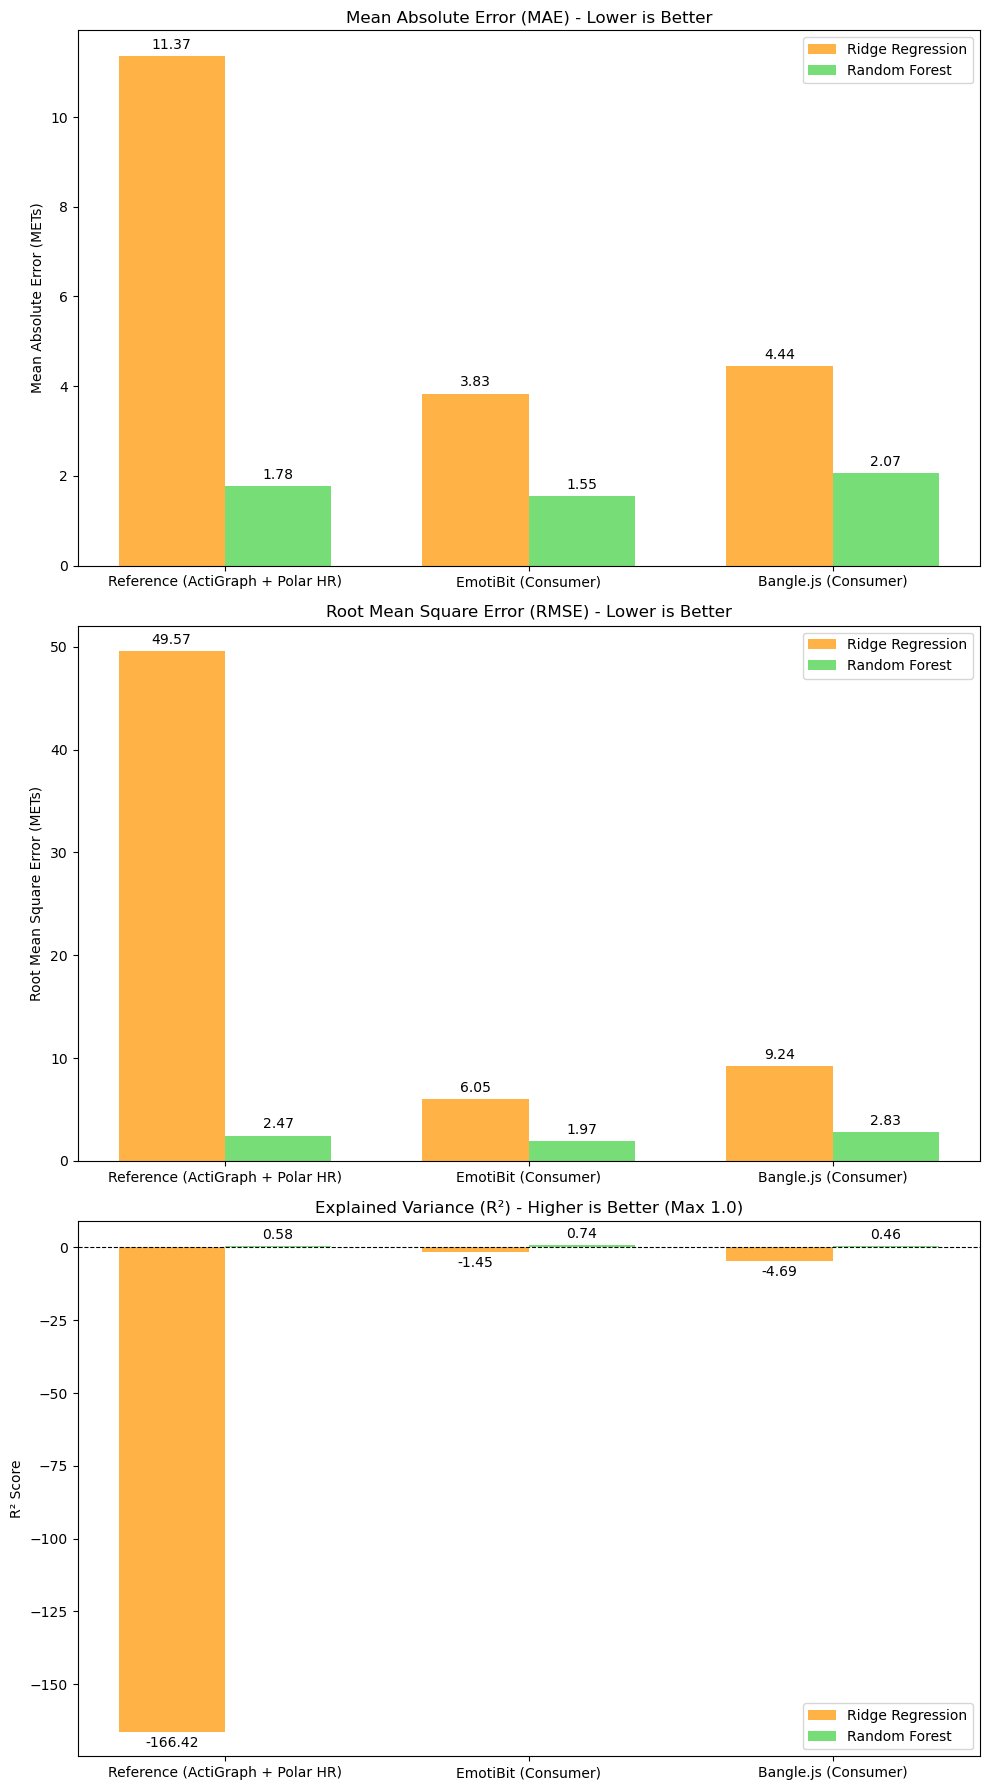

In [8]:
# Extract data for plotting
labels = [SCENARIOS[k]['label'] for k in results.keys()]

rf_maes = [results[k]['Random_Forest']['MAE'] for k in results.keys()]
ridge_maes = [results[k]['Ridge']['MAE'] for k in results.keys()]

rf_rmses = [results[k]['Random_Forest']['RMSE'] for k in results.keys()]
ridge_rmses = [results[k]['Ridge']['RMSE'] for k in results.keys()]

rf_r2 = [results[k]['Random_Forest']['R2'] for k in results.keys()]
ridge_r2 = [results[k]['Ridge']['R2'] for k in results.keys()]

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

# Create 3 subplots
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 18))

# Plot 1: MAE
rects1_mae = ax1.bar(x - width/2, ridge_maes, width, label='Ridge Regression', color='#FFB347')
rects2_mae = ax1.bar(x + width/2, rf_maes, width, label='Random Forest', color='#77DD77')
ax1.set_ylabel('Mean Absolute Error (METs)')
ax1.set_title('Mean Absolute Error (MAE) - Lower is Better')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.legend()
ax1.bar_label(rects1_mae, padding=3, fmt='%.2f')
ax1.bar_label(rects2_mae, padding=3, fmt='%.2f')

# Plot 2: RMSE
rects1_rmse = ax2.bar(x - width/2, ridge_rmses, width, label='Ridge Regression', color='#FFB347')
rects2_rmse = ax2.bar(x + width/2, rf_rmses, width, label='Random Forest', color='#77DD77')
ax2.set_ylabel('Root Mean Square Error (METs)')
ax2.set_title('Root Mean Square Error (RMSE) - Lower is Better')
ax2.set_xticks(x)
ax2.set_xticklabels(labels)
ax2.legend()
ax2.bar_label(rects1_rmse, padding=3, fmt='%.2f')
ax2.bar_label(rects2_rmse, padding=3, fmt='%.2f')

# Plot 3: R2
rects1_r2 = ax3.bar(x - width/2, ridge_r2, width, label='Ridge Regression', color='#FFB347')
rects2_r2 = ax3.bar(x + width/2, rf_r2, width, label='Random Forest', color='#77DD77')
ax3.set_ylabel('R² Score')
ax3.set_title('Explained Variance (R²) - Higher is Better (Max 1.0)')
ax3.set_xticks(x)
ax3.set_xticklabels(labels)
ax3.legend()
ax3.axhline(0, color='black', linewidth=0.8, linestyle='--') # Baseline 0 line
ax3.bar_label(rects1_r2, padding=3, fmt='%.2f')
ax3.bar_label(rects2_r2, padding=3, fmt='%.2f')

fig.tight_layout()
plt.show()